###***Load & Understand the Data***

***Import Libraries***

In [ ]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


***Basic Data Understanding***

In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


###***Data Cleaning***

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [ ]:
df[['director', 'cast', 'country']].isnull().sum()

,0
director,0
cast,0
country,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [ ]:
df['date_added'].dtype

dtype('<M8[ns]')

### ***Univariate Analysis***

***Movies vs TV Shows***

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
import matplotlib.pyplot as plt

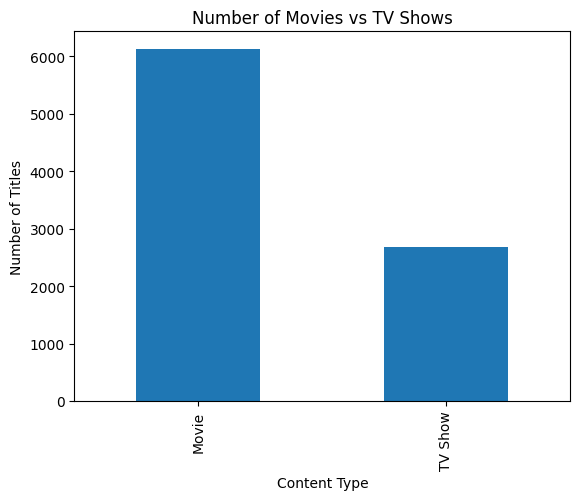

In [ ]:
df['type'].value_counts().plot(kind='bar')

plt.title('Number of Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

***Top 10 Countries Producing Netflix Content***

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


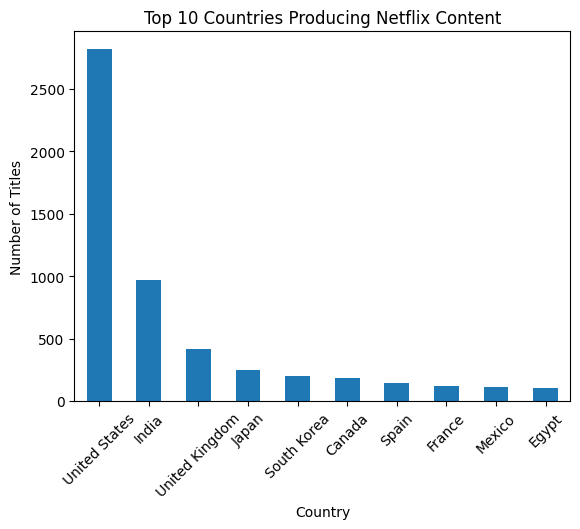

In [ ]:
country_counts = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

country_counts.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

***Top 10 Most Common Genres***

In [ ]:
genre_counts = df['listed_in'].value_counts().head(10)

genre_counts

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


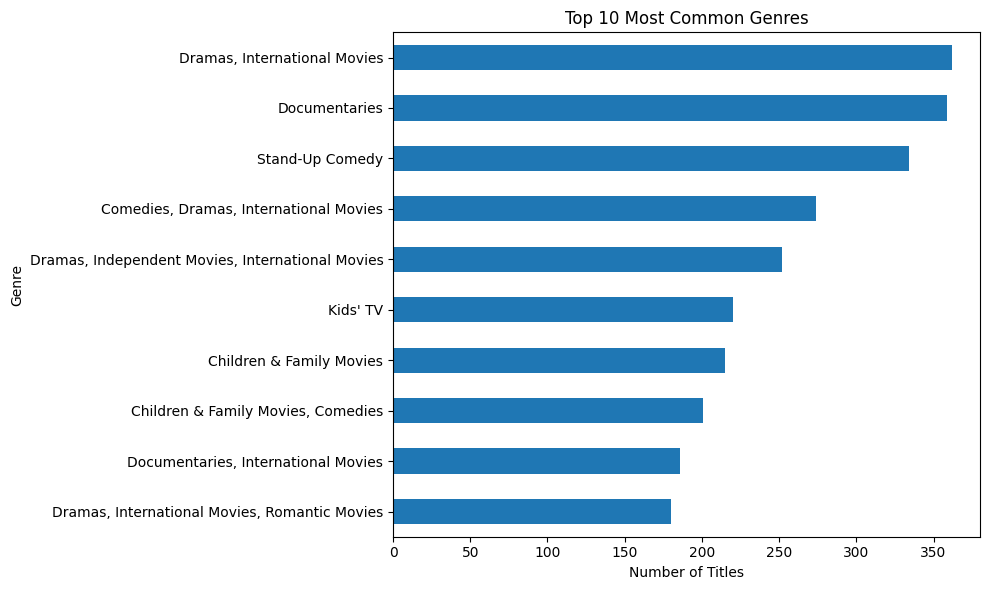

In [ ]:
plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

***Top 10 Most Common Ratings***

In [ ]:
rating_counts = df['rating'].value_counts().head(10)

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


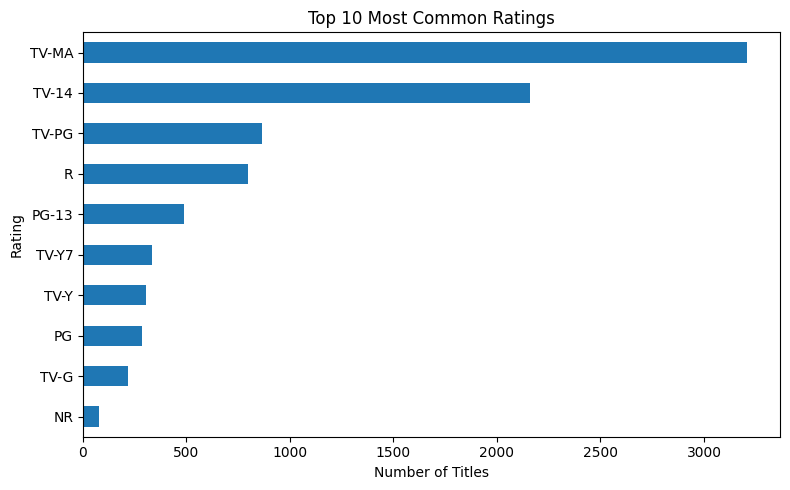

In [ ]:
plt.figure(figsize=(8, 5))

rating_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Common Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

###***Bivariate Analysis***

***Content Released Per Year***

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

year_counts.tail(20)

,count
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


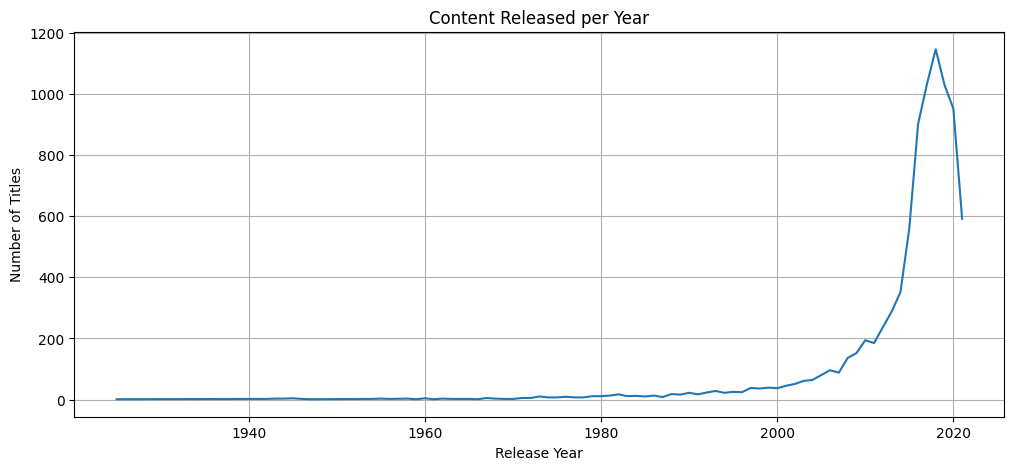

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(year_counts.index, year_counts.values)

plt.title('Content Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.show()

***Movies vs TV Shows in Top 5 Countries***

In [ ]:
top_5_countries = df['country'].value_counts().head(5).index

country_type = (
    df[df['country'].isin(top_5_countries)]
    .groupby(['country', 'type'])
    .size()
    .unstack(fill_value=0)
)

country_type

type,Movie,TV Show
country,,
India,893,79
Japan,76,169
United Kingdom,206,213
United States,2058,760
Unknown,440,391


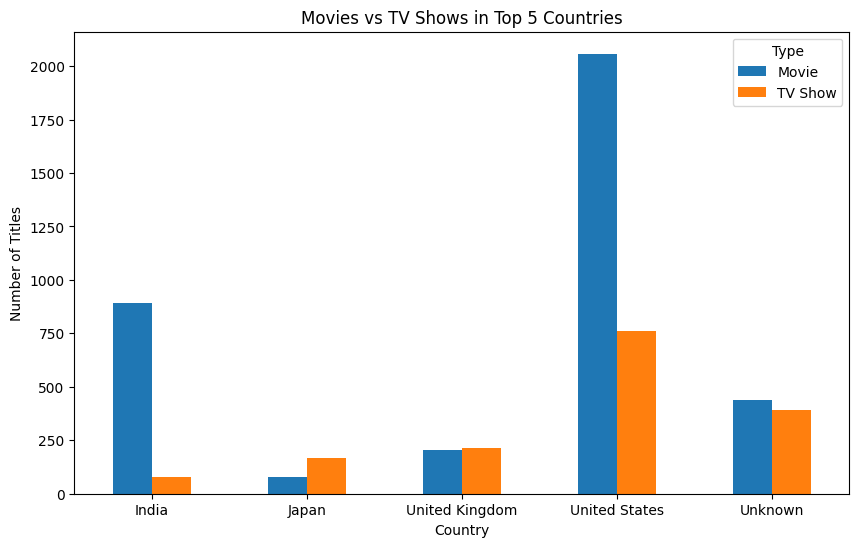

In [ ]:
country_type.plot(kind='bar', figsize=(10, 6))

plt.title('Movies vs TV Shows in Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.legend(title='Type')

plt.show()

***Rating Distributions***

In [ ]:
rating_type = (
    df.groupby(['rating', 'type'])
    .size()
    .unstack(fill_value=0)
)

rating_type

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


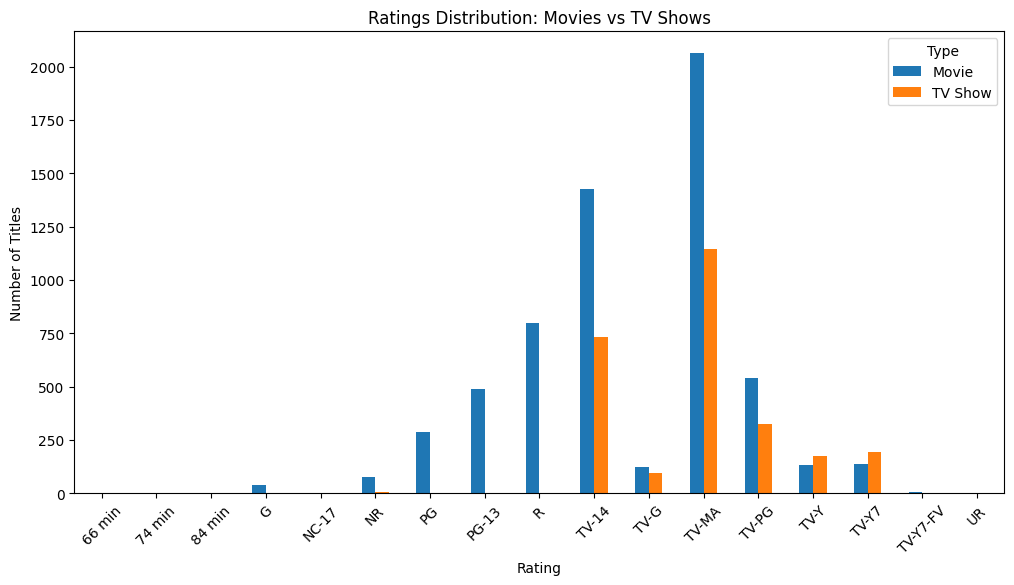

In [ ]:
rating_type.plot(kind='bar', figsize=(12, 6))

plt.title('Ratings Distribution: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')

plt.show()

### ***Key Findings***


---
*   Netflix has more Movies than TV Shows in the dataset.
*   The United States is the leading country in terms of content production, followed by India.
*   “Dramas, International Movies” is the most common genre category in the dataset.
*   TV-MA is the most common rating among the titles.
*   The number of titles released increased significantly in recent years.
*   The distribution of ratings differs between Movies and TV Shows.
